# Explanatory Data Analysis

**Structure of this notebook:**
1. Setup & Data Overview
2. Data Quality Checks
3. Univariate Analysis (distributions)
4. Bivariate / Relationship Analysis (correlations, grouped comparisons)
5. Time-Based Analysis
6. Per-Machine Analysis
7. Multivariate Analysis PCA & t-SNE
8. Summary of Key Findings


## 1. Setup & Data Overview

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [68]:
df = pd.read_csv("../data/raw/smart_manufacturing_data.csv", parse_dates=["timestamp"])
print("Shape:", df.shape)
df.head()


Shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [69]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp                 100000 non-null  datetime64[ns]
 1   machine_id                100000 non-null  int64         
 2   temperature               100000 non-null  float64       
 3   vibration                 100000 non-null  float64       
 4   humidity                  100000 non-null  float64       
 5   pressure                  100000 non-null  float64       
 6   energy_consumption        100000 non-null  float64       
 7   machine_status            100000 non-null  int64         
 8   anomaly_flag              100000 non-null  int64         
 9   predicted_remaining_life  100000 non-null  int64         
 10  failure_type              100000 non-null  object        
 11  downtime_risk             100000 non-null  float64       
 12  mai

**Observations:**
- 100,000 rows, 13 columns.
- One row per machine per minute (approximately), covering 50 machines.
- Mix of numeric sensor readings (temperature, vibration, humidity, pressure,
  energy_consumption), status/label columns (machine_status, anomaly_flag,
  maintenance_required), a categorical failure label (failure_type), and two
  derived columns (predicted_remaining_life, downtime_risk).

In [70]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,100000,NaN,NaN,NaN,2025-02-04 17:19:29.999999744,2025-01-01 00:00:00,2025-01-18 08:39:45,2025-02-04 17:19:30,2025-02-22 01:59:15,2025-03-11 10:39:00,NaN
machine_id,100000.0,NaN,NaN,NaN,25.49933,1.0,13.0,25.0,38.0,50.0,14.389439
temperature,100000.0,NaN,NaN,NaN,75.015625,35.55,68.2675,75.06,81.75,121.94,10.031884
vibration,100000.0,NaN,NaN,NaN,50.01227,-17.09,39.97,49.96,60.1,113.8,14.985444
humidity,100000.0,NaN,NaN,NaN,54.995401,30.0,42.52,54.98,67.5,80.0,14.43796
pressure,100000.0,NaN,NaN,NaN,3.000405,1.0,2.0,3.01,4.0,5.0,1.152399
energy_consumption,100000.0,NaN,NaN,NaN,2.747064,0.5,1.63,2.74,3.87,5.0,1.297865
machine_status,100000.0,NaN,NaN,NaN,1.00205,0.0,1.0,1.0,1.0,2.0,0.446193
anomaly_flag,100000.0,NaN,NaN,NaN,0.08916,0.0,0.0,0.0,0.0,1.0,0.284976
predicted_remaining_life,100000.0,NaN,NaN,NaN,234.26916,1.0,97.0,230.0,365.0,499.0,150.063062


## 2. Data Quality Checks

In [71]:
# Missing values
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:" if len(missing) else "No missing values found.")
missing


No missing values found.


Series([], dtype: int64)

In [72]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Duplicate (machine_id, timestamp) pairs — should be unique if data is well-formed
print("Duplicate (machine_id, timestamp) pairs:", df.duplicated(subset=["machine_id", "timestamp"]).sum())


Duplicate rows: 0
Duplicate (machine_id, timestamp) pairs: 0


In [73]:
print("Number of unique machines:", df["machine_id"].nunique())
print("Timestamp range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("Failure type categories:", df["failure_type"].unique().tolist())


Number of unique machines: 50
Timestamp range: 2025-01-01 00:00:00 to 2025-03-11 10:39:00
Failure type categories: ['Normal', 'Vibration Issue', 'Overheating', 'Pressure Drop', 'Electrical Fault']


**Observations:**
- No missing values and no duplicate rows the dataset is clean, so no imputation
  or deduplication is required before modelling.
- 50 distinct machines, sampled at ~1-minute intervals over roughly 10 weeks
  (Jan 1 – Mar 11, 2025).
- `failure_type` has 5 categories: `Normal`, `Vibration Issue`, `Overheating`,
  `Pressure Drop`, `Electrical Fault`.

## 3. Univariate Analysis

### 3.1 Numeric feature distributions

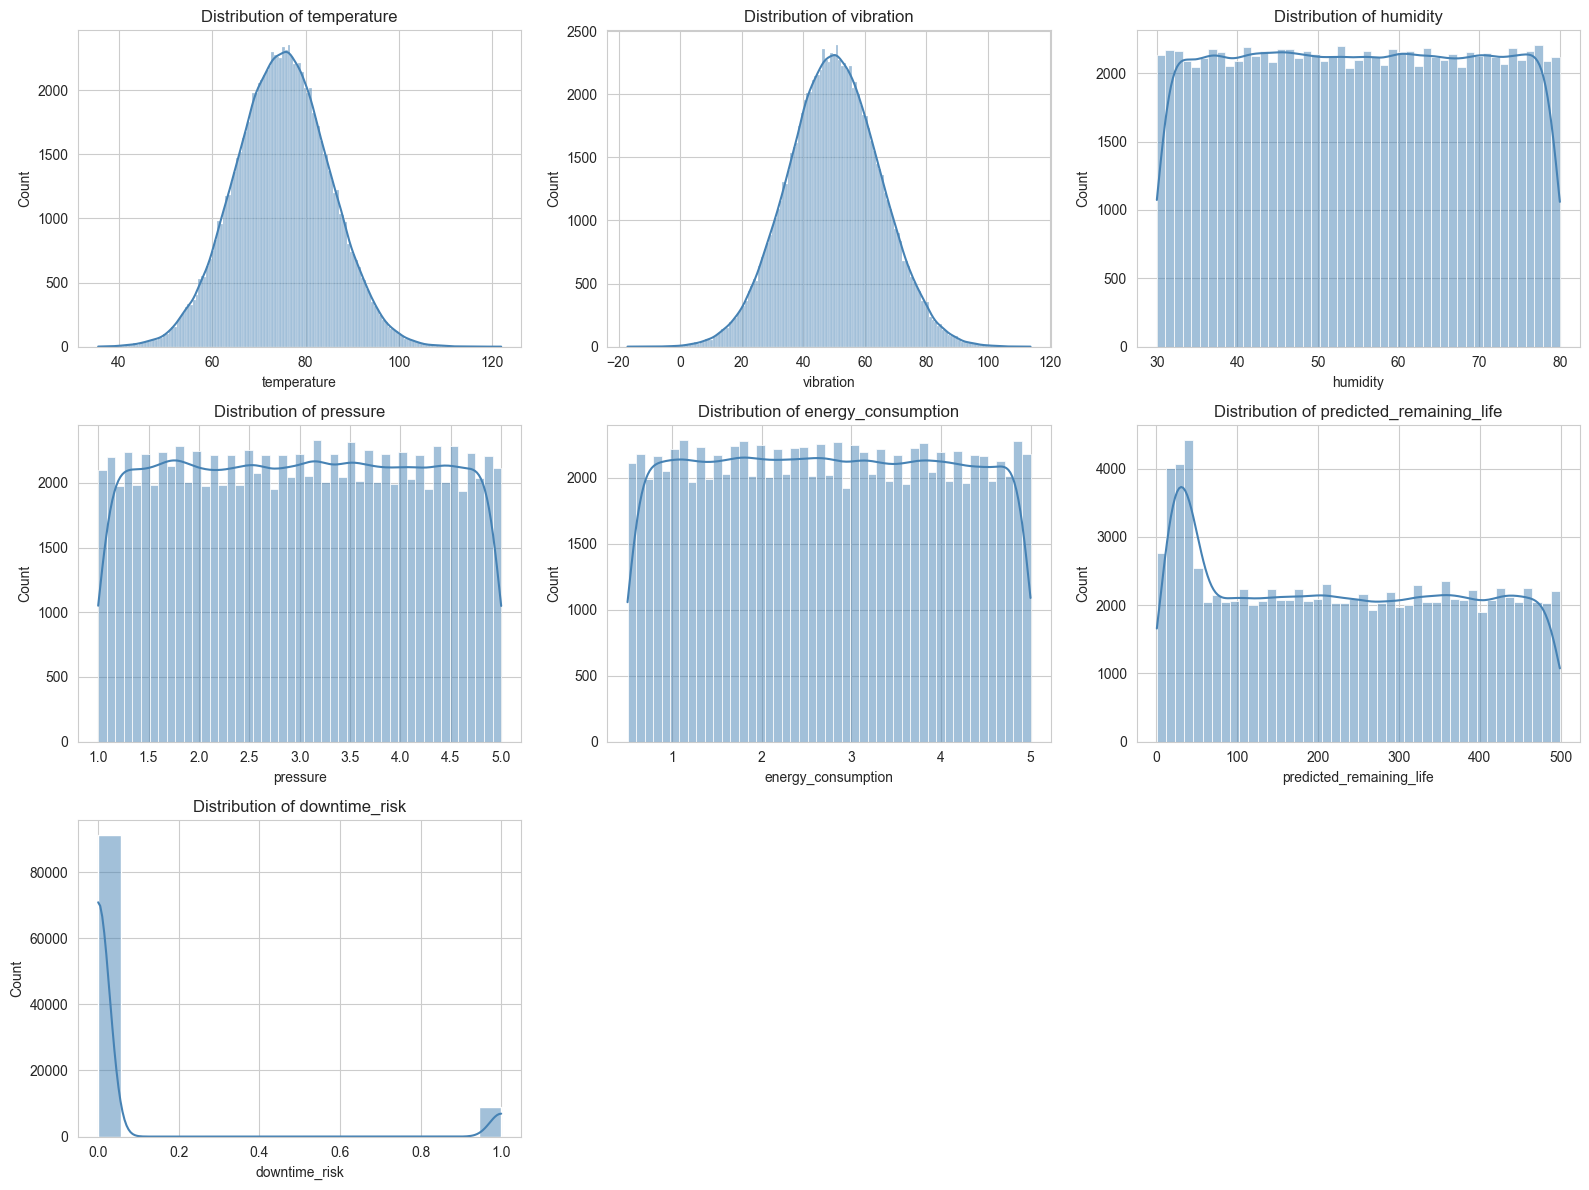

In [74]:
numeric_cols = ["temperature", "vibration", "humidity", "pressure",
                "energy_consumption", "predicted_remaining_life", "downtime_risk"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


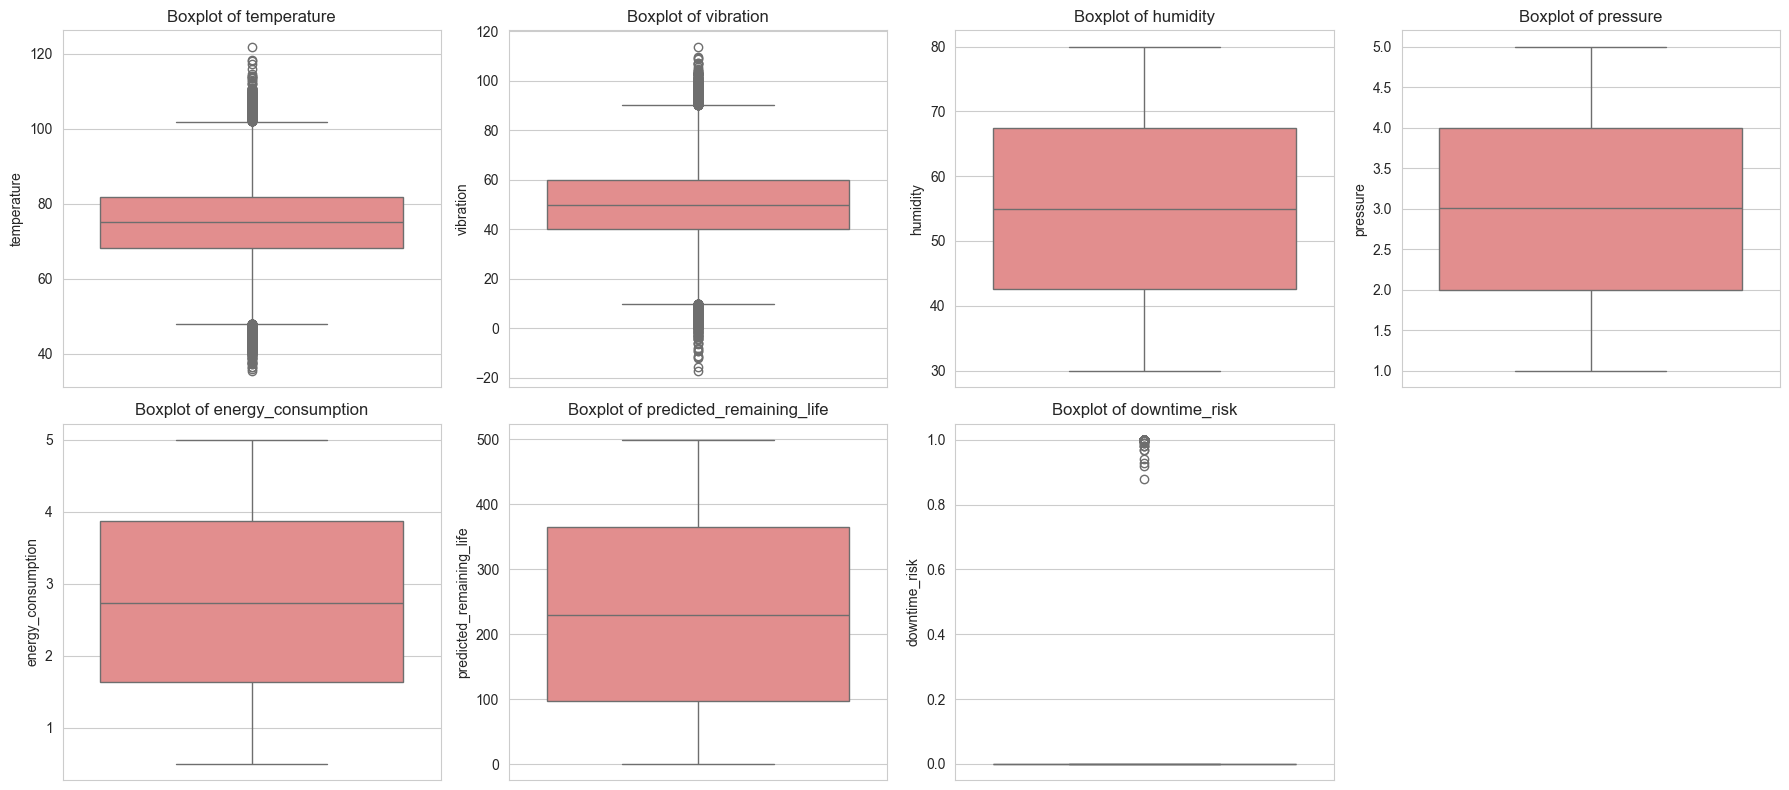

In [75]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**Observations:**
- Sensor readings (temperature, vibration, humidity, pressure, energy_consumption)
  each show a fairly wide spread, consistent with normal operating variation plus
  a smaller number of extreme readings that line up with fault events (checked in
  Section 4).
- `predicted_remaining_life` and `downtime_risk` are the derived risk indicators —
  worth watching for a bimodal pattern (healthy vs at-risk machines).
- Boxplots highlight outliers in most sensor columns; these are **not removed**
  at this stage since they likely correspond to genuine anomaly/failure events
  rather than data errors, this will be revisited during preprocessing in Task 2.

### 3.2 Categorical / label distributions

C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\1646163377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="machine_status", data=df, ax=axes[0, 0], palette="viridis")
C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\1646163377.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="anomaly_flag", data=df, ax=axes[0, 1], palette="viridis")
C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\1646163377.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="maintenance_required", data=df, ax=axes[1, 0], palette="viridis")
C:\Users\

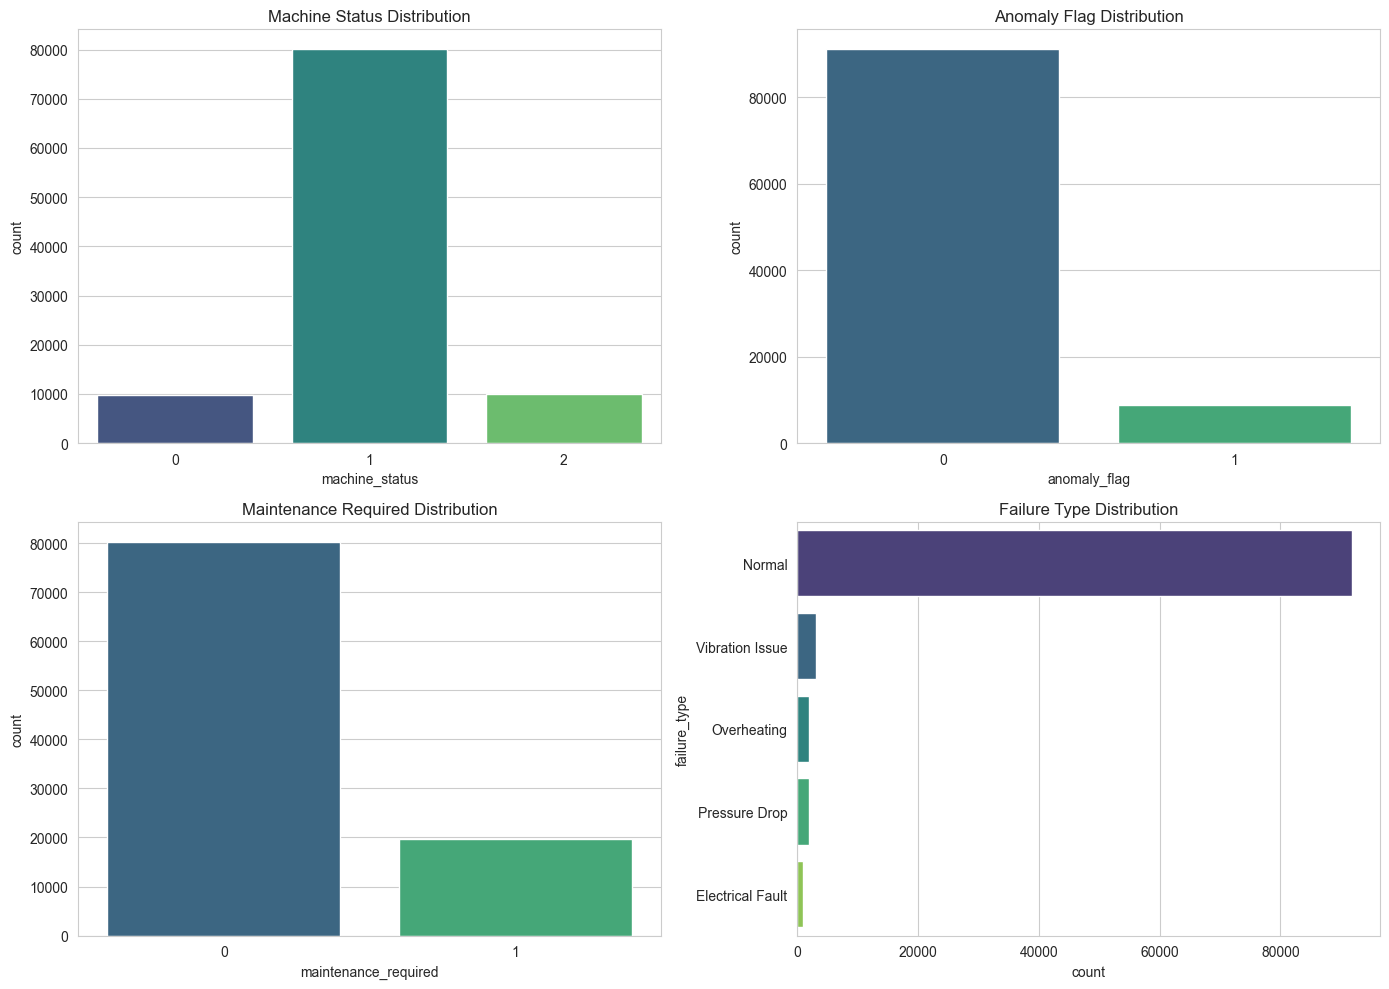

failure_type
Normal              91.9%
Vibration Issue     3.13%
Overheating         1.99%
Pressure Drop       1.97%
Electrical Fault    1.01%
Name: proportion, dtype: object


In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x="machine_status", data=df, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Machine Status Distribution")

sns.countplot(x="anomaly_flag", data=df, ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Anomaly Flag Distribution")

sns.countplot(x="maintenance_required", data=df, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Maintenance Required Distribution")

order = df["failure_type"].value_counts().index
sns.countplot(y="failure_type", data=df, order=order, ax=axes[1, 1], palette="viridis")
axes[1, 1].set_title("Failure Type Distribution")

plt.tight_layout()
plt.show()

print(df["failure_type"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


**Observations — important for Task 2 modelling:**
- `failure_type` is **heavily imbalanced**: ~92% of rows are `Normal`, with the
  four fault types each making up only 1–3% of the data (Vibration Issue 3.1%,
  Overheating 2.0%, Pressure Drop 2.0%, Electrical Fault 1.0%).
- `maintenance_required` is also imbalanced (~80% not required vs ~20% required).
- This imbalance means accuracy alone would be a misleading metric later,
  precision/recall/F1 or a resampling strategy should be considered when
  building the PyCaret pipeline.

## 4. Bivariate / Relationship Analysis

### 4.1 Correlation between numeric variables

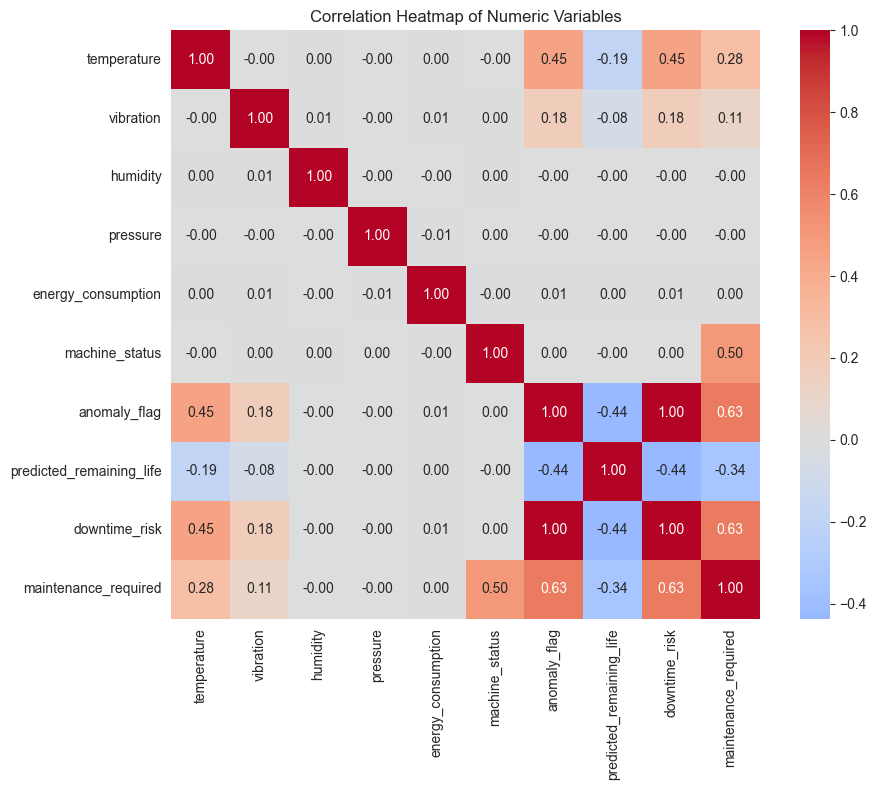

In [77]:
corr_cols = ["temperature", "vibration", "humidity", "pressure", "energy_consumption",
             "machine_status", "anomaly_flag", "predicted_remaining_life",
             "downtime_risk", "maintenance_required"]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


**Observations:**
- `maintenance_required` correlates most strongly with `anomaly_flag` (~0.63),
  `downtime_risk` (~0.63), and `machine_status` (~0.50), and negatively with
  `predicted_remaining_life` (~-0.34) machines with less predicted remaining
  life are more likely to need maintenance.
- Raw sensor readings (temperature, vibration, humidity, pressure,
  energy_consumption) show weak *linear* correlation with each other and with
  the target labels this suggests failures are driven by combinations/thresholds
  of sensor values rather than simple linear relationships, which motivates the
  multivariate analysis in Section 7.

### 4.2 Sensor readings by failure type

C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\613894305.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="failure_type", y=col, data=df, order=order, ax=axes[i], palette="Set2")
C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\613894305.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="failure_type", y=col, data=df, order=order, ax=axes[i], palette="Set2")
C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\613894305.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="failure_type", y=col, data=df, order=order, ax=axes[i], pa

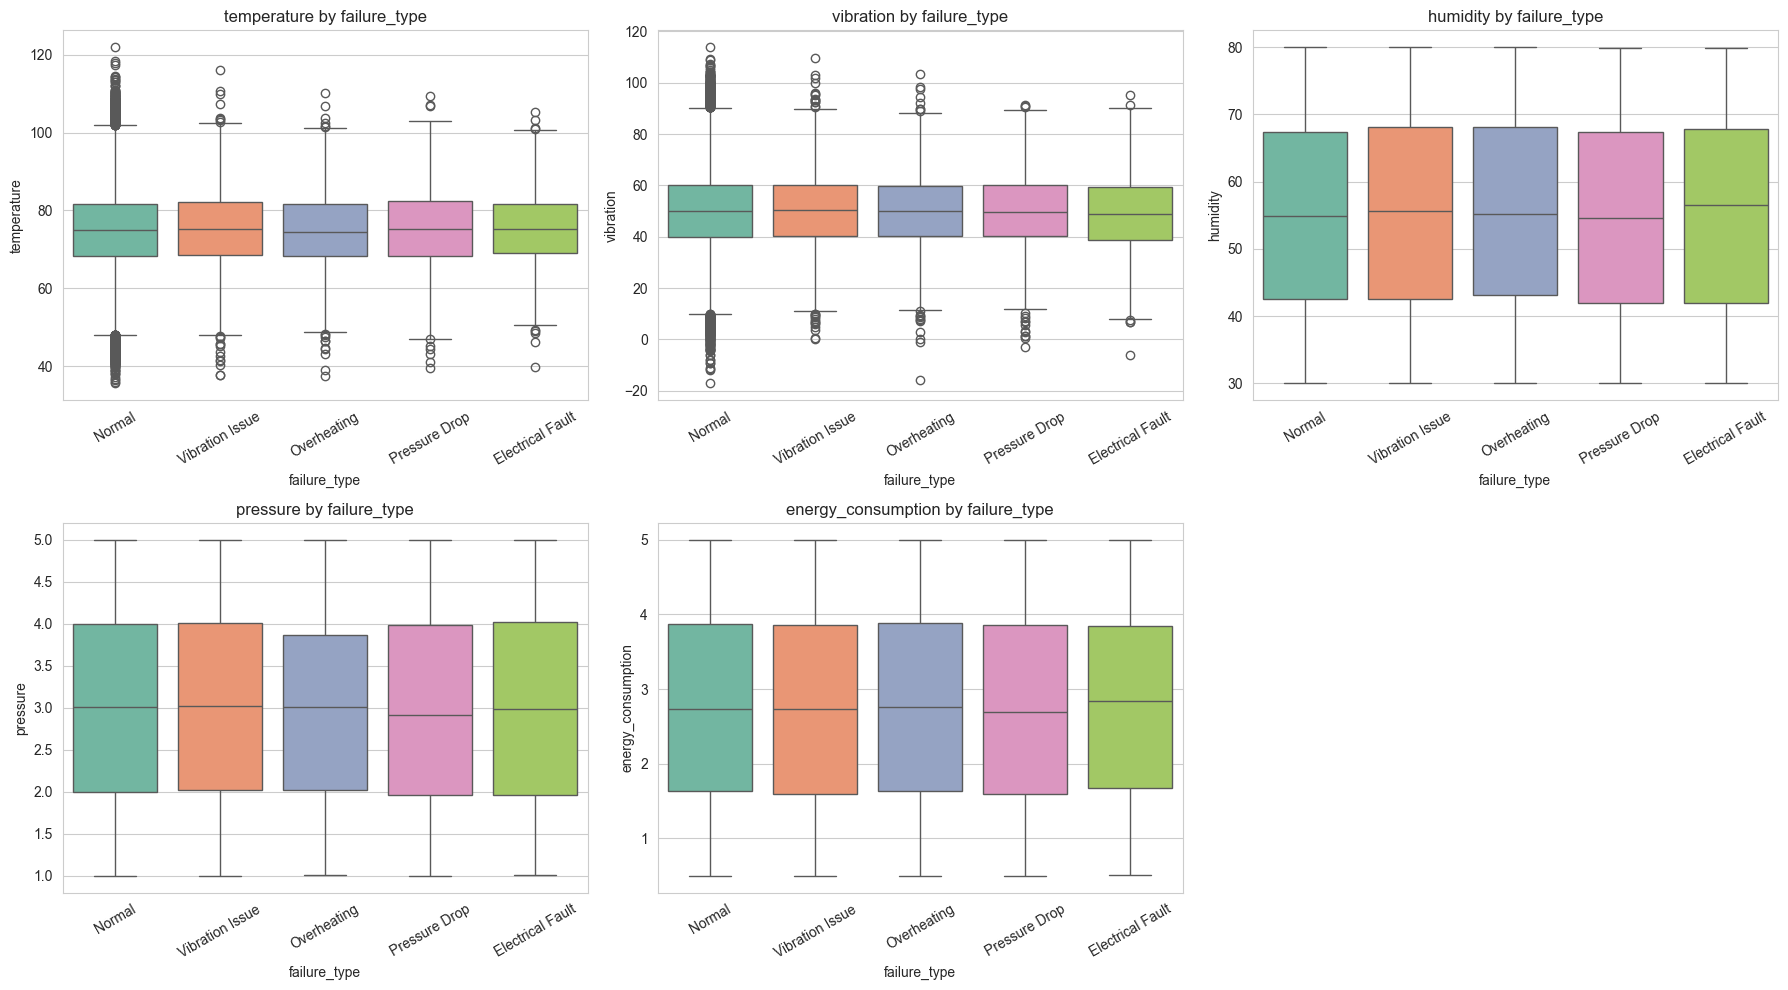

In [78]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sensor_cols = ["temperature", "vibration", "humidity", "pressure", "energy_consumption"]
axes = axes.flatten()

order = df["failure_type"].value_counts().index
for i, col in enumerate(sensor_cols):
    sns.boxplot(x="failure_type", y=col, data=df, order=order, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} by failure_type")
    axes[i].tick_params(axis="x", rotation=30)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


**Observations:**
- `Overheating` events line up with visibly elevated `temperature` compared to
  `Normal` operation, as expected.
- `Vibration Issue` events show a higher `vibration` spread than `Normal`.
- `Pressure Drop` events show lower `pressure` readings.
- This confirms the sensor columns carry genuine signal for predicting
  `failure_type`, even though the linear correlations in 4.1 were weak (the
  relationship is threshold/interaction-based, not linear).

### 4.3 Sensor readings by maintenance_required

C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\1604249676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="maintenance_required", y=col, data=df, ax=axes[i], palette="Set1")
C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\1604249676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="maintenance_required", y=col, data=df, ax=axes[i], palette="Set1")
C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\1604249676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="maintenance_required", y=col, data=df, ax=axes[i], palette="Set1"

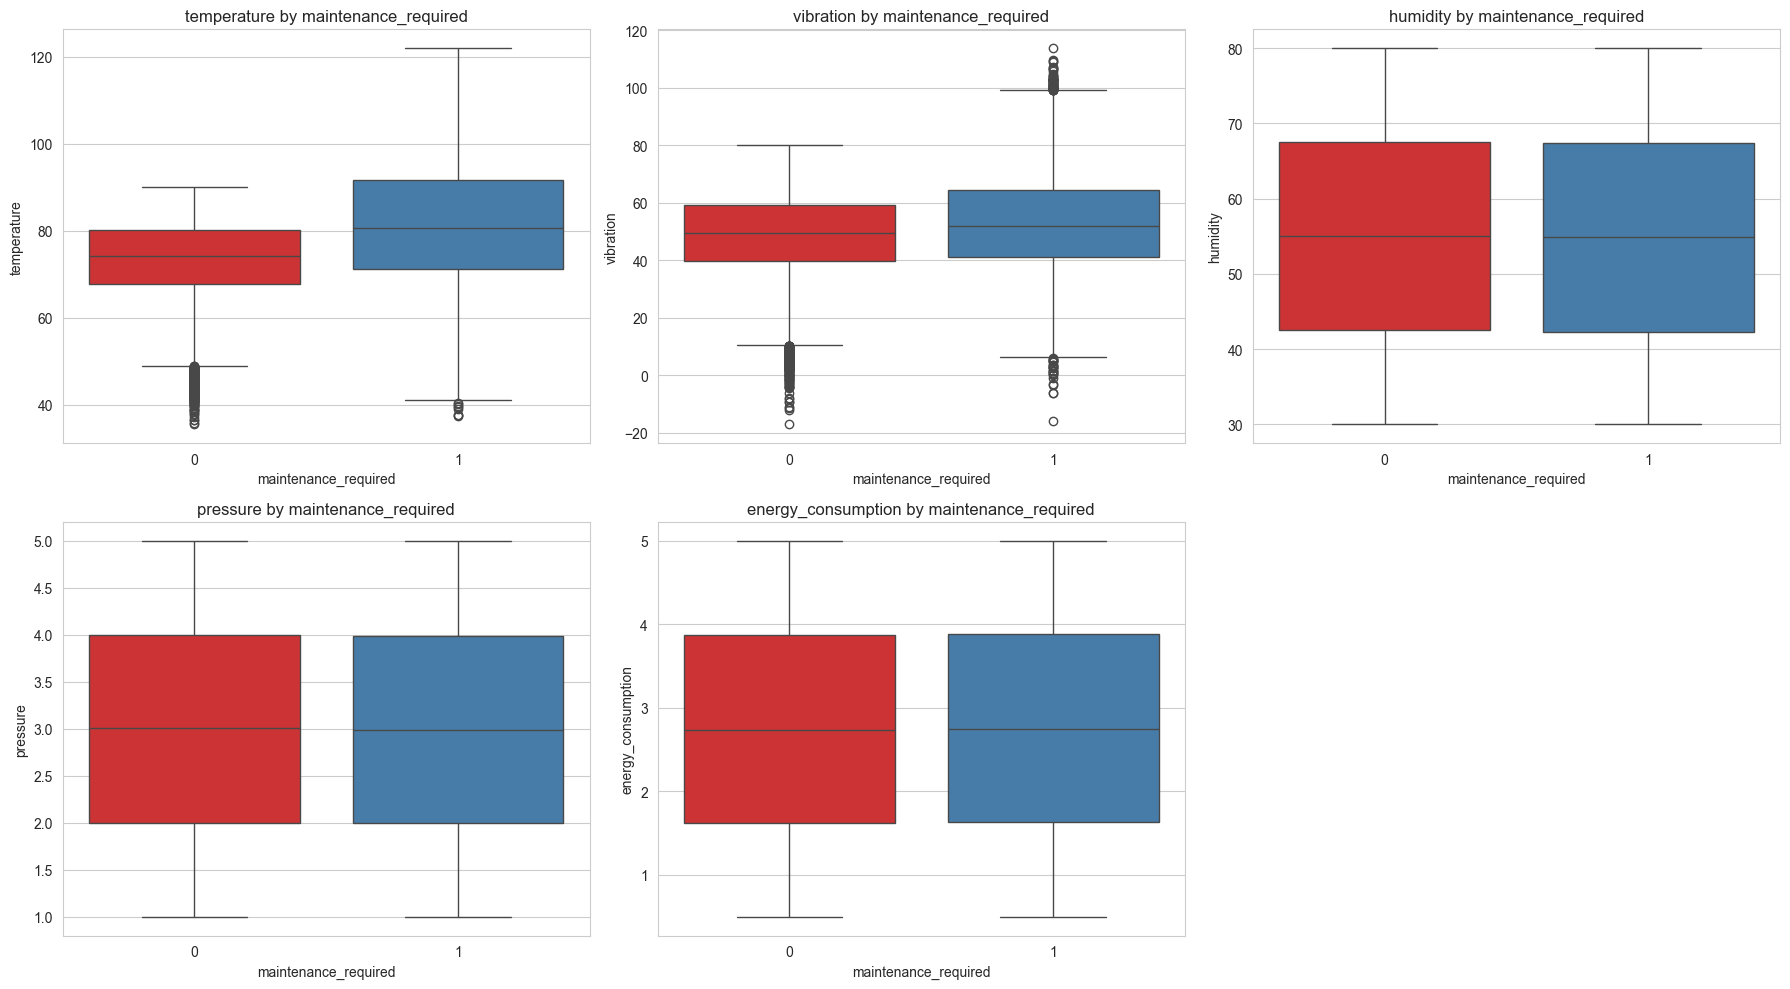

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(sensor_cols):
    sns.boxplot(x="maintenance_required", y=col, data=df, ax=axes[i], palette="Set1")
    axes[i].set_title(f"{col} by maintenance_required")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


### 4.4 downtime_risk and predicted_remaining_life vs maintenance_required

C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\2207756006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="maintenance_required", y="downtime_risk", data=df, ax=axes[0], palette="Set2")
C:\Users\glenv\AppData\Local\Temp\ipykernel_25280\2207756006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="maintenance_required", y="predicted_remaining_life", data=df, ax=axes[1], palette="Set2")


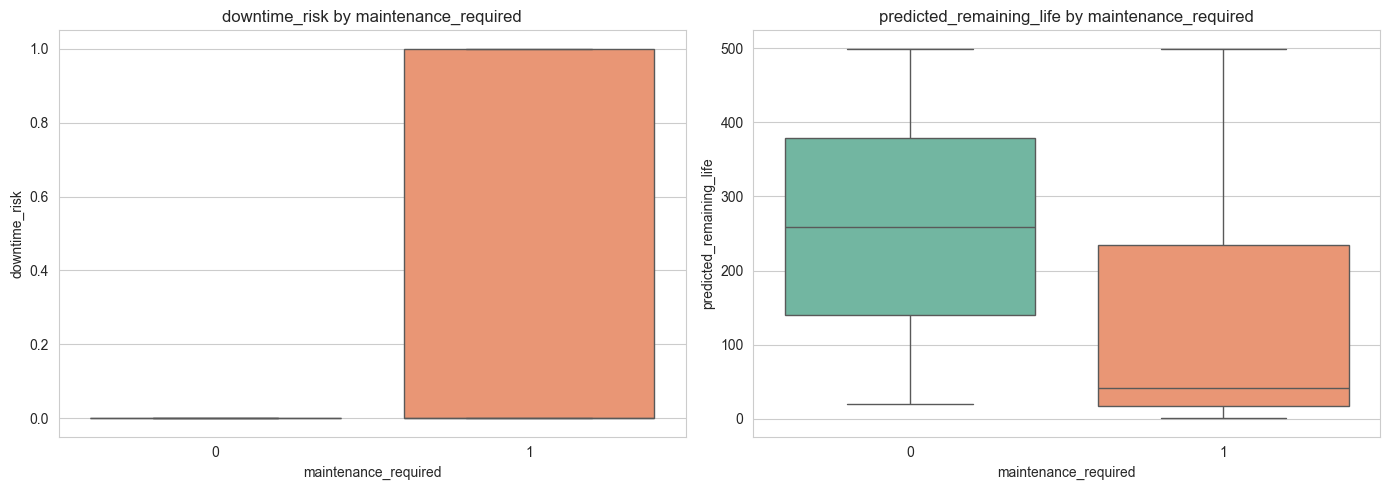

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="maintenance_required", y="downtime_risk", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("downtime_risk by maintenance_required")

sns.boxplot(x="maintenance_required", y="predicted_remaining_life", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("predicted_remaining_life by maintenance_required")
plt.tight_layout()
plt.show()


**Observations:**
- Machines flagged for `maintenance_required` show clearly higher `downtime_risk`
  and lower `predicted_remaining_life`, confirming these two derived features are
  strong (almost definitional) predictors of the maintenance label and should be
  treated carefully in Task 2, e.g. checking whether they are legitimate
  leading indicators or effectively leak the target.

## 5. Time-Based Analysis

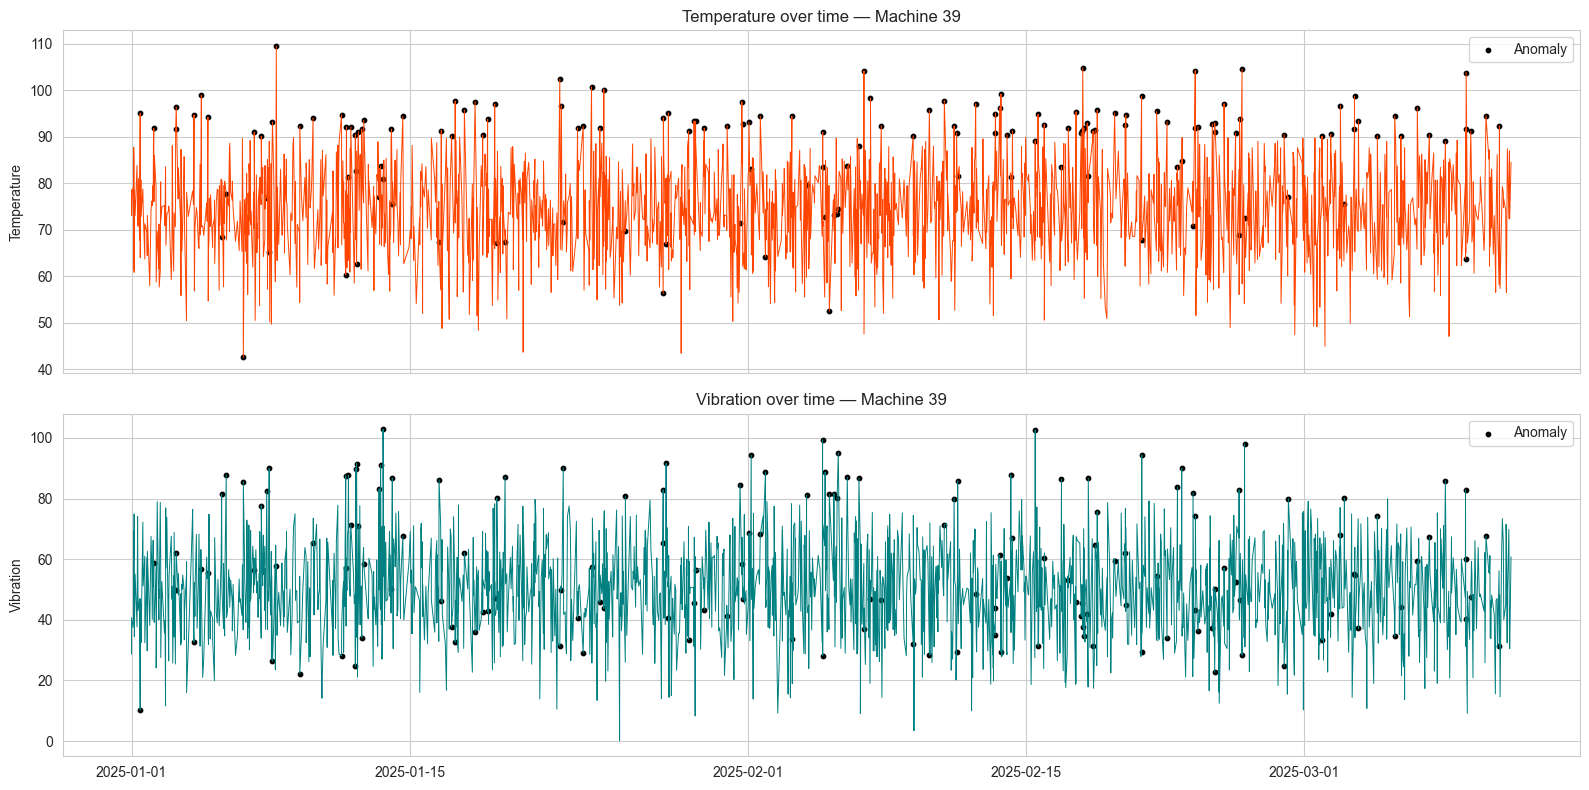

In [81]:
single_machine = df[df["machine_id"] == df["machine_id"].iloc[0]].sort_values("timestamp")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(single_machine["timestamp"], single_machine["temperature"], color="orangered", linewidth=0.7)
axes[0].set_title(f"Temperature over time — Machine {single_machine['machine_id'].iloc[0]}")
axes[0].set_ylabel("Temperature")

axes[1].plot(single_machine["timestamp"], single_machine["vibration"], color="teal", linewidth=0.7)
axes[1].set_title(f"Vibration over time — Machine {single_machine['machine_id'].iloc[0]}")
axes[1].set_ylabel("Vibration")

anomalies = single_machine[single_machine["anomaly_flag"] == 1]
axes[0].scatter(anomalies["timestamp"], anomalies["temperature"], color="black", s=10, label="Anomaly")
axes[1].scatter(anomalies["timestamp"], anomalies["vibration"], color="black", s=10, label="Anomaly")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


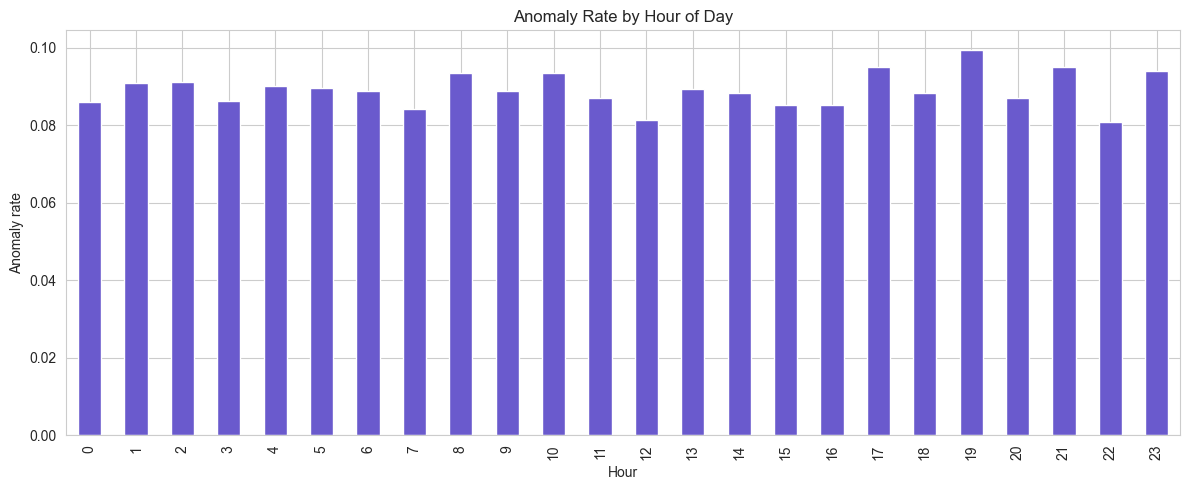

In [82]:
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

hourly_anomaly_rate = df.groupby("hour")["anomaly_flag"].mean()

plt.figure(figsize=(12, 5))
hourly_anomaly_rate.plot(kind="bar", color="slateblue")
plt.title("Anomaly Rate by Hour of Day")
plt.ylabel("Anomaly rate")
plt.xlabel("Hour")
plt.tight_layout()
plt.show()


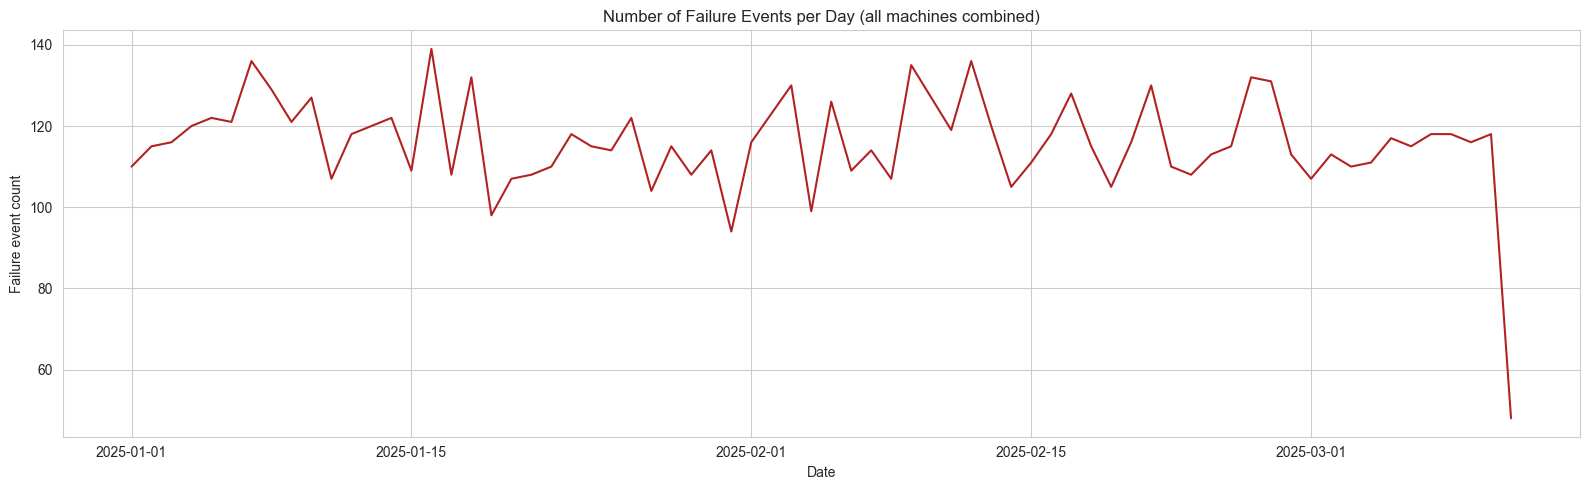

In [83]:
daily_counts = df.groupby("date")["failure_type"].apply(lambda x: (x != "Normal").sum())

plt.figure(figsize=(16, 5))
daily_counts.plot(color="firebrick")
plt.title("Number of Failure Events per Day (all machines combined)")
plt.ylabel("Failure event count")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


**Observations:**
- Anomaly flags visibly coincide with spikes in temperature/vibration for the
  sampled machine, which is a good sanity check that the anomaly labelling is
  consistent with sensor behaviour.
- Anomaly rate does not show an obvious strong hour-of-day pattern, suggesting
  failures are driven by machine condition rather than time-of-day/shift effects
  (this may differ machine-to-machine, see Section 6).
- Daily failure counts fluctuate but don't show a strong long-term trend within
  the ~10-week window captured.

## 6. Per-Machine Analysis

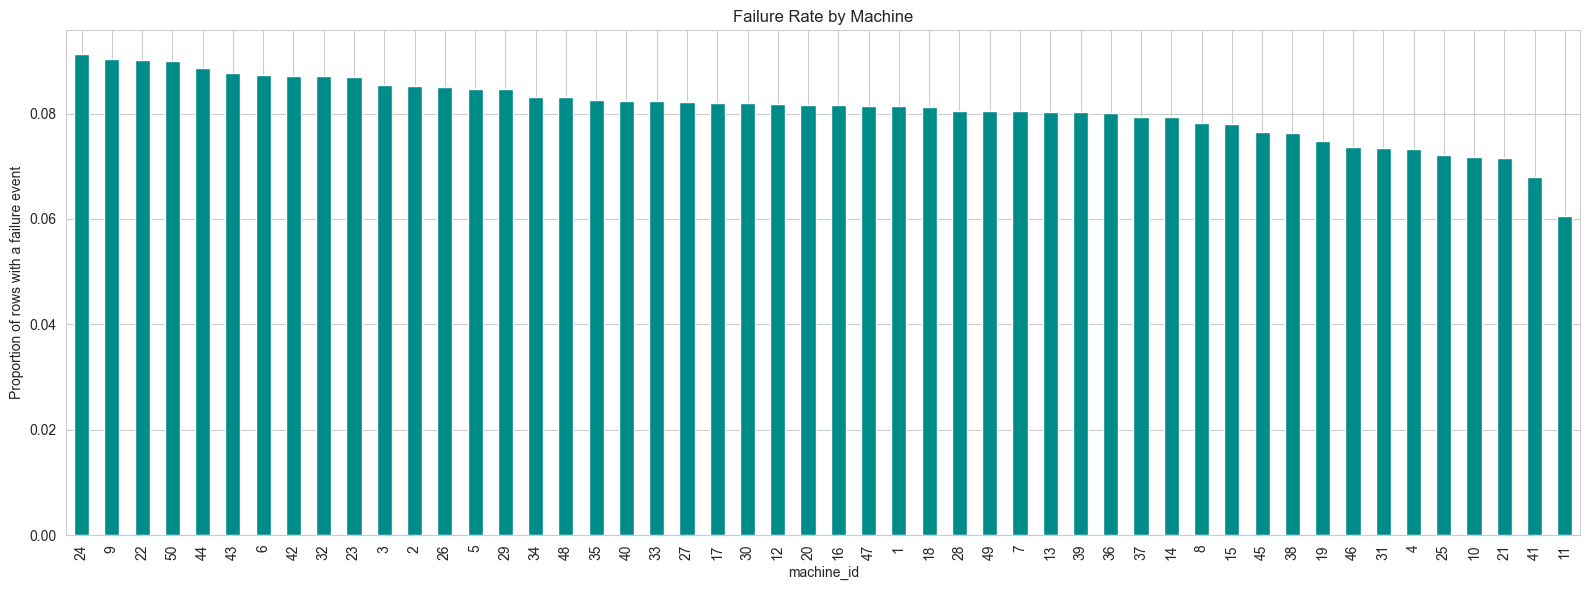

Top 5 machines by failure rate:
machine_id
24    0.091230
9     0.090407
22    0.090103
50    0.089958
44    0.088608
Name: failure_type, dtype: float64

Bottom 5 machines by failure rate:
machine_id
25    0.072072
10    0.071711
21    0.071637
41    0.068058
11    0.060482
Name: failure_type, dtype: float64


In [84]:
is_failure = (df["failure_type"] != "Normal").astype(int)
machine_failure_rate = (
    is_failure.groupby(df["machine_id"])
              .mean()
              .sort_values(ascending=False)
)

plt.figure(figsize=(16, 6))
machine_failure_rate.plot(kind="bar", color="darkcyan")
plt.title("Failure Rate by Machine")
plt.ylabel("Proportion of rows with a failure event")
plt.xlabel("machine_id")
plt.tight_layout()
plt.show()

print("Top 5 machines by failure rate:")
print(machine_failure_rate.head())
print("\nBottom 5 machines by failure rate:")
print(machine_failure_rate.tail())


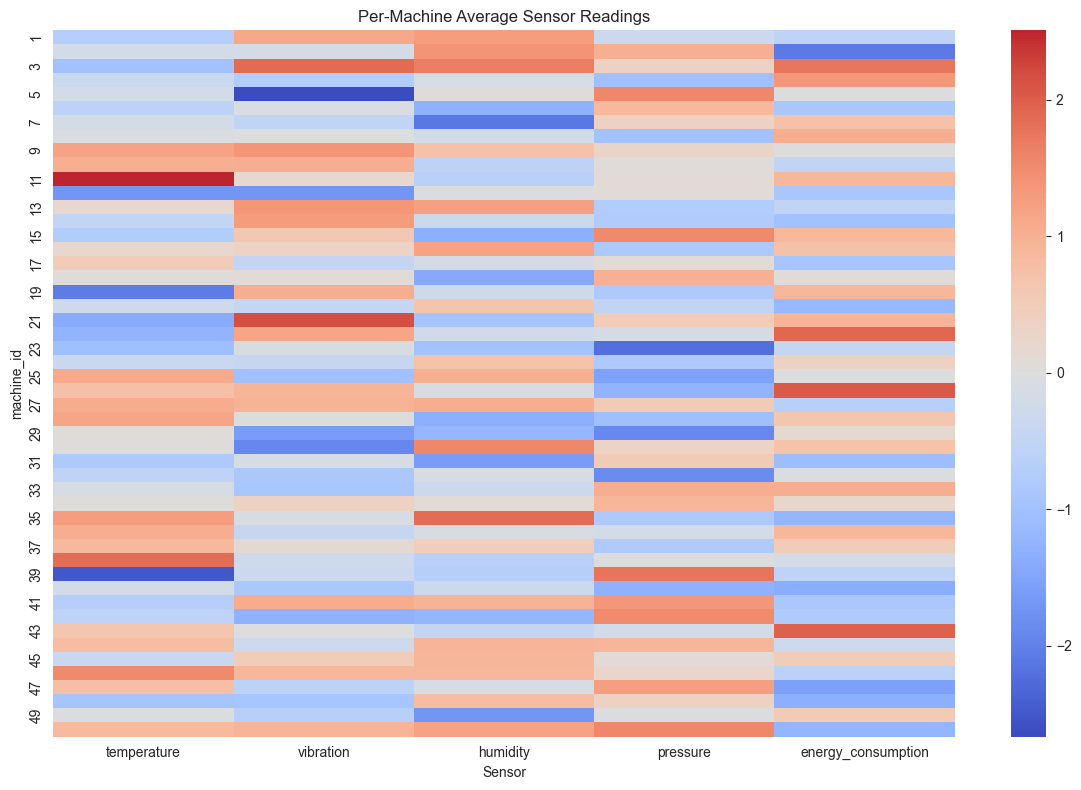

In [90]:
machine_avg_sensors = df.groupby("machine_id")[sensor_cols].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(
    (machine_avg_sensors - machine_avg_sensors.mean()) / machine_avg_sensors.std(),
    cmap="coolwarm", center=0
)
plt.title("Per-Machine Average Sensor Readings")
plt.xlabel("Sensor")
plt.ylabel("machine_id")
plt.tight_layout()
plt.show()


**Observations:**
- Failure rates vary noticeably across the 50 machines and some machines fail
  far more often than others, indicating `machine_id` (or an unobserved
  machine-level factor such as age/model) carries useful predictive signal and
  could be considered as a categorical feature in Task 2.
- Average sensor readings per machine also vary, reinforcing that machine
  identity is not just noise.

## 7. Multivariate Analysis: PCA & t-SNE

The correlation heatmap in Section 4 showed weak *linear* relationships between
sensor readings and the failure/maintenance labels. To check whether the classes
separate in a *non-linear*, multivariate sense, we project the standardised
sensor features into 2D using PCA (linear baseline) and t-SNE (non-linear).

Since t-SNE scales poorly beyond a few thousand points, we take a **stratified
sample** so that the rare failure types remain represented.

In [86]:
feature_cols = ["temperature", "vibration", "humidity", "pressure",
                "energy_consumption", "downtime_risk", "predicted_remaining_life"]

# Stratified sample: up to 400 rows per failure_type
parts = []
for label, group in df.groupby("failure_type"):
    parts.append(group.sample(min(len(group), 400), random_state=RANDOM_STATE))
sample = pd.concat(parts).reset_index(drop=True)

print("Sample size:", sample.shape[0])
print(sample["failure_type"].value_counts())

X = StandardScaler().fit_transform(sample[feature_cols])

Sample size: 2000
failure_type
Electrical Fault    400
Normal              400
Overheating         400
Pressure Drop       400
Vibration Issue     400
Name: count, dtype: int64


Explained variance ratio: [0.25147899 0.14892196]


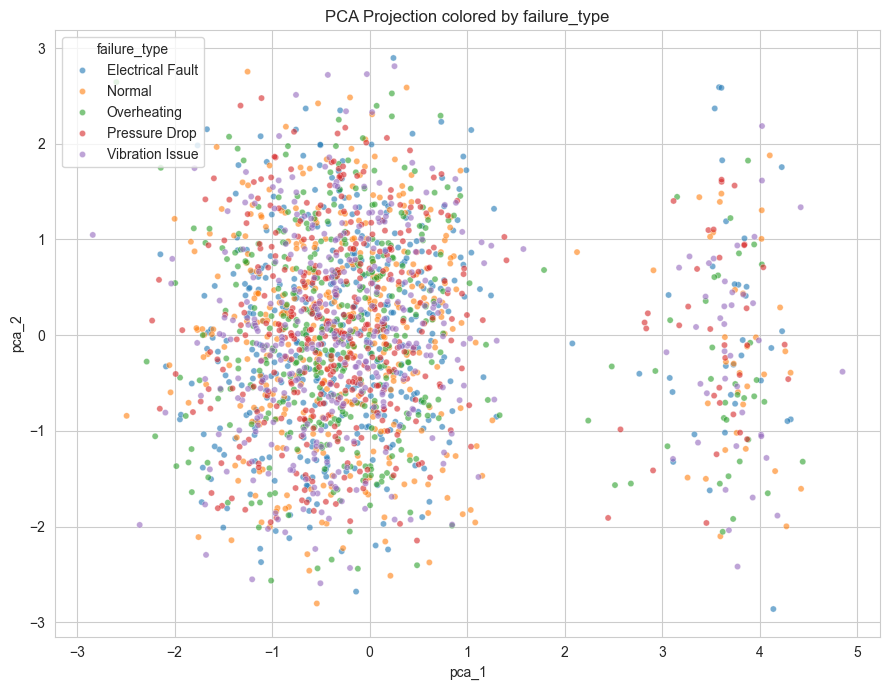

In [87]:
# PCA (linear baseline)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
sample["pca_1"], sample["pca_2"] = X_pca[:, 0], X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(9, 7))
sns.scatterplot(x="pca_1", y="pca_2", hue="failure_type", data=sample,
                 palette="tab10", alpha=0.6, s=20)
plt.title("PCA Projection colored by failure_type")
plt.tight_layout()
plt.show()


In [89]:
import plotly.express as px

# t-SNE (non-linear, 3D, interactive)
tsne = TSNE(n_components=3, perplexity=30, random_state=RANDOM_STATE, init="pca")
X_tsne = tsne.fit_transform(X)
sample["tsne_1"], sample["tsne_2"], sample["tsne_3"] = X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2]

fig = px.scatter_3d(
    sample, x="tsne_1", y="tsne_2", z="tsne_3",
    color="failure_type",
    hover_data=["machine_id", "maintenance_required", "anomaly_flag", "downtime_risk"],
    opacity=0.9,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D t-SNE Projection colored by failure_type")
fig.show()

fig = px.scatter_3d(
    sample, x="tsne_1", y="tsne_2", z="tsne_3",
    color=sample["maintenance_required"].astype(str),
    hover_data=["machine_id", "failure_type", "anomaly_flag", "downtime_risk"],
    opacity=0.9,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D t-SNE Projection colored by maintenance_required")
fig.show()

**Observations:**
- PCA's two components capture only a modest share of the total variance and
  show substantial overlap between failure types — consistent with the weak
  linear correlations found earlier.
- The 3D t-SNE projection shows **tighter, more distinguishable groupings** for
  some failure types than PCA does (e.g. Overheating and Pressure Drop points
  clustering into separate regions of the embedding), suggesting the
  relationship between sensor readings and failure type is non-linear. The third
  dimension adds a little extra separation over the 2D version, though the broad
  structure is similar.
- `maintenance_required` shows a visible tendency for its two classes to occupy
  different regions of the t-SNE space, matching the strong correlations found
  in Section 4 with `downtime_risk` and `predicted_remaining_life`.
- Some overlap remains, which is expected given normal operating noise, this
  supports using non-linear models (e.g. tree-based ensembles) rather than
  purely linear models in the PyCaret pipeline for Task 2.
- The plots are interactive (Plotly): they can be rotated, zoomed, and hovered
  to inspect individual points and their labels.

## 8. Summary of Key Findings

1. **Clean data**: no missing values or duplicates; no imputation required.
2. **Class imbalance**: `failure_type` (~92% Normal) and `maintenance_required`
   (~80% not required) are both imbalanced; this must be handled in Task 2
   (e.g. class weights, resampling, or metric choice beyond accuracy).
3. **Weak linear, strong non-linear signal**: raw correlations between sensors
   and labels are weak, but grouped boxplots and the t-SNE projection show real
   separation, meaning failures are driven by threshold/interaction effects
   rather than simple linear relationships.
4. **Derived features are highly predictive of maintenance**: `downtime_risk`
   and `predicted_remaining_life` correlate strongly with `maintenance_required`;
   worth checking for potential target leakage before modelling.
5. **Machine-level variation**: failure rates and average sensor readings
   differ meaningfully across the 50 machines, so `machine_id` may be a useful
   categorical feature.
6. **Time patterns**: anomalies align with visible spikes in sensor readings
   at the individual-machine level, but no strong global time-of-day trend was
   found in this ~10-week window.

These findings directly inform the preprocessing and modelling choices made in
the PyCaret pipeline (Task 2): feature scaling, handling of class imbalance, and
inclusion of machine-level and time-derived features.